<a href="https://colab.research.google.com/github/Urshuaige/ChinaAdminDivisonSHP/blob/master/computational_geometry_simple_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computational Geometry Exercise — Simple Notebook
This notebook follows Section **6.2 Simple Exercise**. Run cells from top to bottom.


## 0) Setup Environment

In [ ]:
# If you are in Colab and need to install packages (uncomment next line):
# !pip install shapely geopandas matplotlib pandas --quiet

import math
import shapely
import networkx as nx
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import Point, LineString, Polygon
from shapely.ops import unary_union

print("Environment ready.")

Environment ready.


## 1) Create Basic Geometries and Inspect Properties

In [ ]:
# 1.1 Points — Point(x, y) or Point(x, y, z)
p1 = Point(2, 3)
p2 = Point(8, 6)

# 1.2 LineString — LineString([(x1, y1), (x2, y2), ...])
line = LineString([(1, 1), (4, 7)])

# 1.3 Polygon — Polygon(shell, holes=None)
poly1 = Polygon([(1, 1), (1, 9), (9, 9), (9, 1)])

print("Point p1:", p1.wkt)
print("Point p2:", p2.wkt)
print("Line length:", line.length)
print("Polygon area:", poly1.area, " perimeter(length):", poly1.length)

Point p1: POINT (2 3)
Point p2: POINT (8 6)
Line length: 6.708203932499369
Polygon area: 64.0  perimeter(length): 32.0


## 2) Visualize with Matplotlib

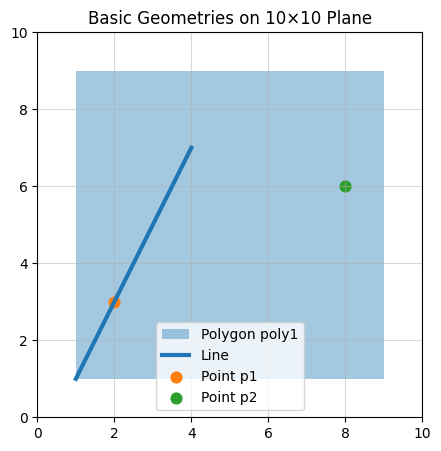

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))

# Polygon
px, py = poly1.exterior.xy
ax.fill(px, py, alpha=0.4, label="Polygon poly1")

# Line
lx, ly = line.xy
ax.plot(lx, ly, linewidth=3, label="Line")

# Points
ax.scatter([p1.x], [p1.y], s=60, label="Point p1")
ax.scatter([p2.x], [p2.y], s=60, label="Point p2")

ax.set_title("Basic Geometries on 10×10 Plane")
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.5)
ax.legend()
plt.show()

## 3) Spatial Operations: Intersection / Union / Difference

Intersection area: 24.0
Union area: 67.0
Difference area (poly1 - poly2): 40.0


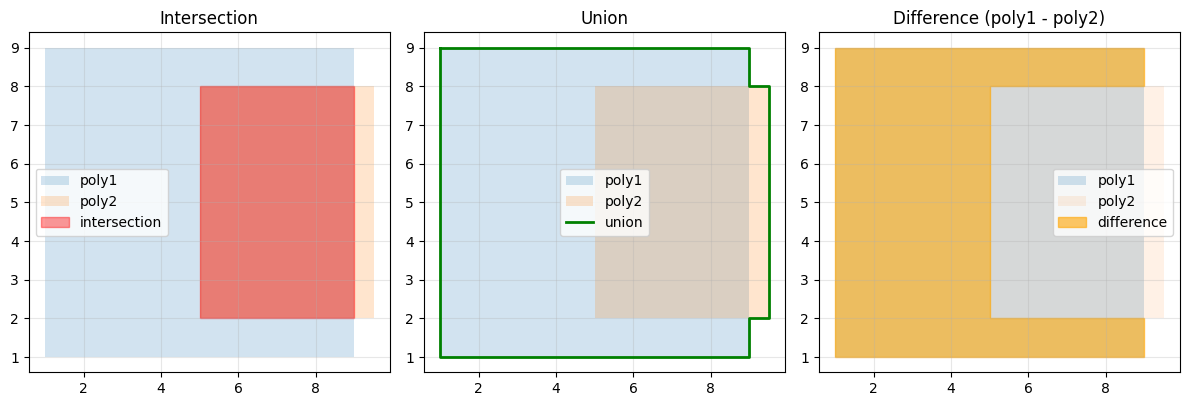

In [ ]:
# Create an overlapping polygon
poly2 = Polygon([(5, 2), (5, 8), (9.5, 8), (9.5, 2)])

# Compute overlay results
inter_geom = poly1.intersection(poly2)
union_geom = poly1.union(poly2)
diff_geom  = poly1.difference(poly2)

print("Intersection area:", inter_geom.area)
print("Union area:", union_geom.area)
print("Difference area (poly1 - poly2):", diff_geom.area)

# Plot results side by side
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Intersection
axes[0].fill(*poly1.exterior.xy, alpha=0.2, label="poly1")
axes[0].fill(*poly2.exterior.xy, alpha=0.2, label="poly2")
if not inter_geom.is_empty:
    if inter_geom.geom_type == "Polygon":
        axes[0].fill(*inter_geom.exterior.xy, color="red", alpha=0.4, label="intersection")
    else:
        for geom in getattr(inter_geom, "geoms", []):
            axes[0].fill(*geom.exterior.xy, color="red", alpha=0.4, label="intersection")
axes[0].set_title("Intersection")
axes[0].set_aspect("equal"); axes[0].grid(True, alpha=0.3); axes[0].legend()

# Union
axes[1].fill(*poly1.exterior.xy, alpha=0.2, label="poly1")
axes[1].fill(*poly2.exterior.xy, alpha=0.2, label="poly2")
if union_geom.geom_type == "Polygon":
    axes[1].plot(*union_geom.exterior.xy, color="green", linewidth=2, label="union")
else:
    for geom in getattr(union_geom, "geoms", []):
        axes[1].plot(*geom.exterior.xy, color="green", linewidth=2, label="union")
axes[1].set_title("Union")
axes[1].set_aspect("equal"); axes[1].grid(True, alpha=0.3); axes[1].legend()

# Difference
axes[2].fill(*poly1.exterior.xy, alpha=0.2, label="poly1")
axes[2].fill(*poly2.exterior.xy, alpha=0.1, label="poly2")
if not diff_geom.is_empty:
    if diff_geom.geom_type == "Polygon":
        axes[2].fill(*diff_geom.exterior.xy, color="orange", alpha=0.6, label="difference")
    else:
        for geom in getattr(diff_geom, "geoms", []):
            axes[2].fill(*geom.exterior.xy, color="orange", alpha=0.6, label="difference")
axes[2].set_title("Difference (poly1 - poly2)")
axes[2].set_aspect("equal"); axes[2].grid(True, alpha=0.3); axes[2].legend()

plt.tight_layout()
plt.show()

## 4) Pandas + GeoPandas: Build GeoDataFrame and Filter

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

df = pd.DataFrame({
    "id":    [1, 2, 3, 4, 5],
    "lon":   [2.5, 3.0, 7.5, 8.0, 5.5],
    "lat":   [2.0, 8.0, 5.0, 2.0, 7.5],
    "value": [5, 12, 8, 20, 15],
})
display(df)

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs=None)
display(gdf.head())

gdf_filtered = gdf[gdf["value"] >= 10].copy()
display(gdf_filtered)

,id,lon,lat,value
0,1,2.5,2.0,5
1,2,3.0,8.0,12
2,3,7.5,5.0,8
3,4,8.0,2.0,20
4,5,5.5,7.5,15


,id,lon,lat,value,geometry
0,1,2.5,2.0,5,POINT (2.5 2)
1,2,3.0,8.0,12,POINT (3 8)
2,3,7.5,5.0,8,POINT (7.5 5)
3,4,8.0,2.0,20,POINT (8 2)
4,5,5.5,7.5,15,POINT (5.5 7.5)


,id,lon,lat,value,geometry
1,2,3.0,8.0,12,POINT (3 8)
3,4,8.0,2.0,20,POINT (8 2)
4,5,5.5,7.5,15,POINT (5.5 7.5)


## 5) Optional: Buffer and Count Points Within

Buffer area around p1: 12.561324627819012
Points within buffer: 1


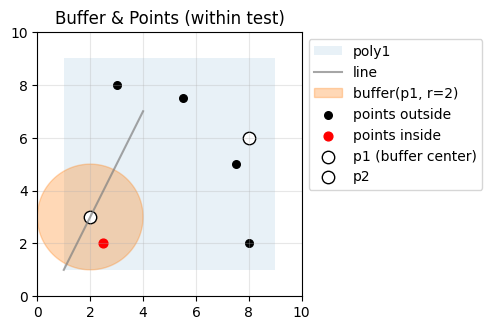

In [ ]:
# Create a buffer around p1
buf = p1.buffer(2, resolution=32)
print("Buffer area around p1:", buf.area)

# Count how many points in gdf fall within buffer
inside_mask = gdf.geometry.within(buf)
count_inside = inside_mask.sum()
print("Points within buffer:", count_inside)

# Visualize buffer and points
fig, ax = plt.subplots(figsize=(5, 5))

# Reference polygon and line
ax.fill(*poly1.exterior.xy, alpha=0.1, label="poly1")
ax.plot(*line.xy, color="gray", alpha=0.7, label="line")

# Buffer
bx, by = buf.exterior.xy
ax.fill(bx, by, alpha=0.3, color="C1", label="buffer(p1, r=2)")

# Points in/out
gdf[~inside_mask].plot(ax=ax, color="black", markersize=30, label="points outside")
gdf[inside_mask].plot(ax=ax, color="red", markersize=40, label="points inside")

# p1/p2 labels
ax.scatter([p1.x], [p1.y], s=80, edgecolors="k", facecolors="white", label="p1 (buffer center)")
ax.scatter([p2.x], [p2.y], s=80, edgecolors="k", facecolors="white", label="p2")

ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Buffer & Points (within test)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()